In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
#import pyccl as ccl
import math
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from functools import partial
from scipy.integrate import quad, dblquad

import pyccl as ccl
import camb
from camb import model, initialpower
import cosmology
import fisher_matrix_local_png

In [2]:
import bias_model

In [10]:
redshift_bg = np.linspace(0.05, 1, 100)
redshift_lrg = np.linspace(0.3, 1.5, 100)
redshift_elg = np.linspace(0.5, 1.6, 100)
redshift_magmax = np.linspace(0.05, 1.6, 100)
redshift_qso = np.linspace(1, 3, 100)
redshift_lbgu = np.linspace(2.5, 3.5, 100)
redshift_lbgg = np.linspace(3.5, 4.5, 100)
redshift_lbgr = np.linspace(4.5, 5.5, 100)
m = [20.5, 21, 24, 21.8, 23.5, 24.5, 25, 25.5]
redshift_axis = [redshift_bg, redshift_lrg, redshift_elg, 
                 redshift_magmax, 
                 redshift_qso, 
                 redshift_lbgu, redshift_lbgg, redshift_lbgr]

In [11]:
h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

def D(z):
    a = 1.0 / (1.0 + np.asarray(z))
    return cosmo.growth_factor(a) / cosmo.growth_factor(1.0)

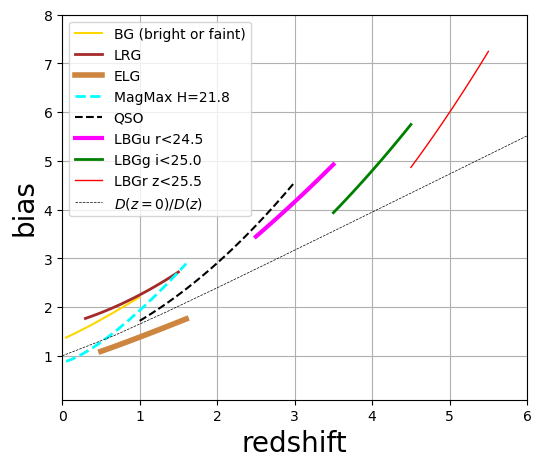

In [14]:
plt.figure(figsize=(6,5))
for i in range(len(redshift_axis)):
    if i == 0:
        plt.plot(redshift_axis[i], bias_model.bias_bg(redshift_axis[i], m[i]), label = f'BG (bright or faint)', color = 'gold')
    if i == 1:
        plt.plot(redshift_axis[i], bias_model.bias_lrg(redshift_axis[i], m[i]), label = f'LRG', color='brown', lw=2)
    if i == 2:
        plt.plot(redshift_axis[i], bias_model.bias_elg(redshift_axis[i], m[i]), label = f'ELG', color='peru',lw=4)
    if i == 3:
        plt.plot(redshift_axis[i], bias_model.bias_magmax(redshift_axis[i], m[i]), '--', label = f'MagMax H={m[i]:.1f}', color='cyan', lw=2)

    if i == 4:
        plt.plot(redshift_axis[i], bias_model.bias_qso(redshift_axis[i], m[i]),  '--', label = f'QSO', color='k')
    if i == 5:
        plt.plot(redshift_axis[i], bias_model.bias_lbg(redshift_axis[i], m[i]), label = f'LBGu r<{m[i]:.1f}', color='magenta',lw=3)
    if i == 6:
        plt.plot(redshift_axis[i], bias_model.bias_lbg(redshift_axis[i], m[i]), label = f'LBGg i<{m[i]:.1f}', color = 'g', lw=2)
    if i == 7:
        plt.plot(redshift_axis[i], bias_model.bias_lbg(redshift_axis[i], m[i]), label = f'LBGr z<{m[i]:.1f}', color='r', lw=1)

plt.xlabel('redshift', fontsize=20)
plt.ylabel('bias', fontsize=20)
plt.ylim(0.1, 8)

plt.plot(np.linspace(0, 6, 10), 1/D(np.linspace(0, 6, 10)), '--k', lw=0.5, label = r'$D(z=0)/D(z)$')
plt.xlim(0, 6)
plt.legend()

plt.grid()